In [2]:
import os
import warnings
from tqdm import tqdm # Tracks progress of loops
import pickle

warnings.filterwarnings('ignore')
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"     # Suppress INFO, WARNING, and ERROR logs from TF/absl

import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import GlobalAveragePooling2D, RandomBrightness, RandomContrast, RandomZoom, RandomRotation, RandomFlip # type:ignore
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2L, preprocess_input
from tensorflow.keras import Sequential # type:ignore
from tensorflow.keras.preprocessing import image 
from tensorflow.keras import Input # type:ignore
from numpy.linalg import norm

In [3]:
Convolution_layer = EfficientNetV2L(
    weights="imagenet",
    include_top=False,
    input_shape=(480, 480, 3)
)
Convolution_layer.trainable = False

m = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.04),
    RandomZoom(0.12),
    RandomContrast(0.15),
    RandomBrightness(0.15),
    Convolution_layer,
    GlobalAveragePooling2D()
])

473176280/473176280 ━━━━━━━━━━━━━━━━━━━━ 529s 1us/step


In [4]:
def ImageExtractor(img_path, model):

    img = image.load_img(img_path, target_size=(480,480)) 
    img_array = image.img_to_array(img)
    expanded_img_array = np.expand_dims(img_array, axis=0) # # add batch dimension: (480,480,3) -> (1,480,480,3)
    preprocessed_img = preprocess_input(expanded_img_array)
    result = model.predict(preprocessed_img, verbose = 0).flatten()
    normalized_result = result / norm(result)

    return normalized_result

folder_path = 'C:\\Users\\sulem\\OneDrive\\Desktop\\Codes\\ML\\Datasets\\Fashion Images'

filenames = []
for file in os.listdir(folder_path):
    filenames.append(os.path.join(folder_path, file))

validity = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')
filenames = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith(validity)]
filenames = filenames[:5000]  # keep only the first 5,000

feature_list = []
for file in tqdm(filenames):
    feature_list.append(ImageExtractor(file, m))

pickle.dump(feature_list, open('embeddings.pkl', 'wb'))
pickle.dump(filenames, open('filenames.pkl', 'wb'))

  0%|          | 0/5000 [00:00<?, ?it/s]

100%|██████████| 5000/5000 [1:09:45<00:00,  1.19it/s]


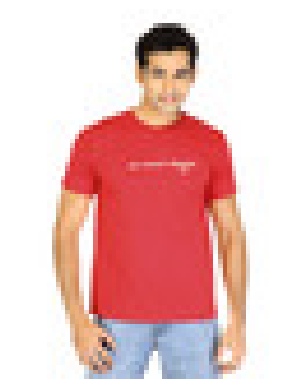

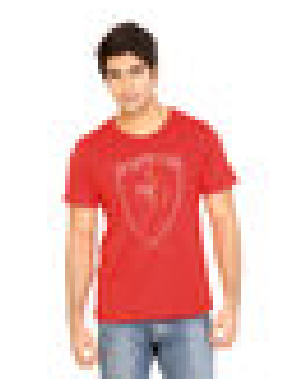

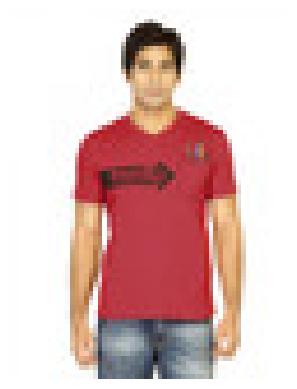

In [9]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import cv2

feature_list = np.array(pickle.load(open('embeddings.pkl','rb')))
filenames = pickle.load(open('filenames.pkl','rb'))

normalized_result = ImageExtractor('C:\\Users\\sulem\\OneDrive\\Desktop\\Codes\\ML\\Datasets\\Fashion Images\\6686.jpg', m)

neighbors = NearestNeighbors(n_neighbors=4, algorithm='brute', metric='euclidean')
neighbors.fit(feature_list)
distances, indices = neighbors.kneighbors([normalized_result])
# print(indices)

for file in indices[0][1:4]:
    temp_img = cv2.imread(filenames[file])
    temp_img = cv2.cvtColor(temp_img, cv2.COLOR_BGR2RGB)  # cv2 loads as BGR, matplotlib expects RGB
    plt.imshow(temp_img)
    plt.axis('off')
    plt.show()